In [102]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

In [103]:
df = pd.read_csv('exoplanet_data.csv', comment = '#')
print(df.shape) #there are 596 rows and 92 columns 
print(df.columns)
# i dont know what st_tefferr2, pl_insol, pl_sinsolerr1, pl_radeerr1, or pl_eqtlim is 

(596, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [104]:
df_new = df[["pl_name","hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]].copy()
df_new.dropna(inplace=True)

print(df_new.head(10))


       pl_name  hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3     DMPP-1 b    DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5     DMPP-1 c    DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7     DMPP-1 d    DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8     DMPP-1 e    DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
9     DMPP-2 b    DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
11  DMPP-3 A b  DMPP-3 A  Radial Velocity        K0 V   854.0   0.008118
60    G 9-40 b    G 9-40          Transit      M2.5 V   456.0   0.036812
62    GJ 143 b    GJ 143          Transit        K4.5   422.0   0.071422
71    GJ 357 b    GJ 357          Transit      M2.5 V   525.0   0.005789
73    GJ 357 b    GJ 357          Transit      M2.5 V   548.0   0.005758


In [105]:
print(df_new.value_counts(df_new["discoverymethod"]))
#there are 3 different discovery methods (transit: 60, radial velocity: 13, and imaging:2)
print(df_new.shape) #75 rows and 6 columns 

discoverymethod
Transit            60
Radial Velocity    13
Imaging             2
Name: count, dtype: int64
(75, 6)


In [106]:
methods = df["discoverymethod"].unique()
print(methods)

['Radial Velocity' 'Transit' 'Disk Kinematics' 'Imaging' 'Microlensing'
 'Transit Timing Variations' 'Eclipse Timing Variations']


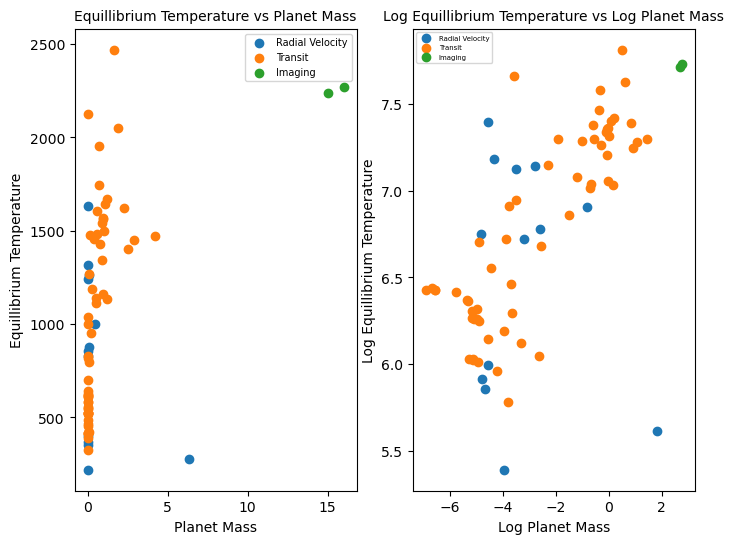

In [107]:
mass = df_new["pl_bmassj"]
temp = df_new["pl_eqt"]
fig, axs = plt.subplots(figsize = (8,6), nrows = 1, ncols = 2)

methods = df_new["discoverymethod"].unique()
for method in methods: 
    mask = df_new["discoverymethod"] == method
    axs[0].scatter(mass[mask],
                   temp[mask],
                  label = method)
axs[0].set_xlabel("Planet Mass")
axs[0].set_ylabel("Equillibrium Temperature")
axs[0].set_title("Equillibrium Temperature vs Planet Mass", fontsize = 10)
axs[0].legend(fontsize = 7)


log_pl_bmasse = np.log(df_new["pl_bmassj"])
log_pl_eqt = np.log(df_new["pl_eqt"])

for method in methods: 
    mask = df_new["discoverymethod"] == method 
    axs[1].scatter(log_pl_bmasse[mask],
                   log_pl_eqt[mask],
                  label = method)
    
axs[1].set_xlabel("Log Planet Mass")
axs[1].set_ylabel("Log Equillibrium Temperature")
axs[1].set_title("Log Equillibrium Temperature vs Log Planet Mass", fontsize = 10)
axs[1].legend(fontsize=5)

plt.show()

In [108]:
#exoplanets found by the imaging method are more likely to be bigger 
mask = df_new["pl_bmassj"] > 5
print(df_new.loc[df_new[mask]["pl_eqt"].idxmin()])
#the sun is a G2V star and the star Epsilon Indi A is orbitign is K5V

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 593, dtype: object


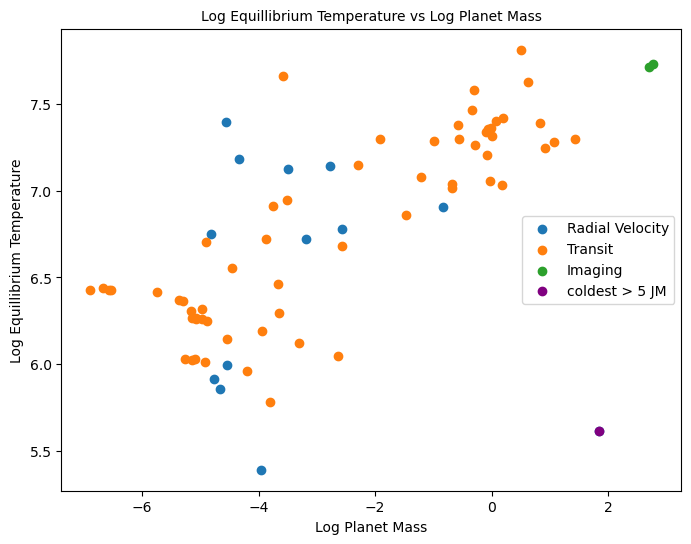

In [128]:
fig, axs = plt.subplots(figsize = (8,6))

log_pl_bmasse = np.log(df_new["pl_bmassj"])
log_pl_eqt = np.log(df_new["pl_eqt"])

methods = df_new["discoverymethod"].unique()
for method in methods: 
    mask = df_new["discoverymethod"] == method 
    axs.scatter(log_pl_bmasse[mask],
                   log_pl_eqt[mask],
                  label = method)
    
axs.scatter(log_pl_bmasse[593],
                log_pl_eqt[593],
                marker = 'o',
                color = 'purple',
                label = 'coldest > 5 JM'
                )
axs.set_xlabel("Log Planet Mass")
axs.set_ylabel("Log Equillibrium Temperature")
axs.set_title("Log Equillibrium Temperature vs Log Planet Mass", fontsize = 10)
axs.legend(loc = 'center right',fontsize=10)

plt.show()

